## Feature Analaysis & Reduction

## Imports

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn import neighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv(r'C:\Users\danie\OneDrive\Desktop\HeartDiseaseTrain.csv')
df

,HeartDisease,Sex,GeneralHealth,MentalHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,...,Smoking,Weight,Height,White,Black,American Indian/Alaskan Native,Asian,Native Hawaiian/Pacific Islander,Other,Hispanic
0,0.0,0.0,2.0,3.0,2.0,8.0,1.0,0.0,1.0,1.0,...,0.0,48.080000,170.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,3.0,1.0,1.0,10.0,1.0,0.0,0.0,0.0,...,1.0,77.110000,163.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,3.0,1.0,1.0,10.0,1.0,0.0,0.0,1.0,...,1.0,79.010897,173.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,13.0,0.0,0.0,0.0,0.0,...,1.0,79.010897,163.588672,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,2.0,1.0,1.0,13.0,1.0,1.0,0.0,0.0,...,1.0,57.150000,168.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318919,0.0,1.0,1.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0,...,1.0,68.490000,170.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
318920,0.0,0.0,3.0,1.0,1.0,13.0,1.0,0.0,0.0,0.0,...,1.0,69.850000,175.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
318921,0.0,1.0,1.0,1.0,1.0,10.0,1.0,0.0,0.0,0.0,...,1.0,113.400000,196.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
318922,0.0,0.0,3.0,1.0,1.0,11.0,1.0,0.0,0.0,0.0,...,1.0,89.810000,170.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Exploration

In [3]:
df.describe()

,HeartDisease,Sex,GeneralHealth,MentalHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,...,Smoking,Weight,Height,White,Black,American Indian/Alaskan Native,Asian,Native Hawaiian/Pacific Islander,Other,Hispanic
count,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,...,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000,318924.000000
mean,0.055411,0.438810,2.412399,1.486379,1.412315,7.445915,0.735580,0.037354,0.087965,0.089015,...,0.829869,78.969933,163.533171,0.759140,0.116680,0.016659,0.023836,0.003236,0.008024,0.072425
std,0.228782,0.496242,1.031491,0.693048,0.667356,3.716508,0.441025,0.189627,0.283244,0.284766,...,0.375749,25.446188,33.907336,0.427606,0.321039,0.127991,0.152539,0.056793,0.089216,0.259190
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.010000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,66.680000,163.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,2.000000,1.000000,1.000000,8.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,79.010897,168.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,3.000000,2.000000,2.000000,11.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,90.720000,178.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,5.000000,3.000000,3.000000,14.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,290.300000,229.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# Check the columns in the dataset
df.columns

Index(['HeartDisease', 'Sex', 'GeneralHealth', 'MentalHealth',
       'PhysicalHealth', 'AgeGroup', 'PhysicalActivity', 'Stroke',
       'SkinCancer', 'Cancer', 'SleepTime', 'COPD', 'KidneyDisease',
       'Diabetic', 'Asthma', 'DifficultyWalking', 'AlcoholConsumption',
       'Smoking', 'Weight', 'Height', 'White', 'Black',
       'American Indian/Alaskan Native', 'Asian',
       'Native Hawaiian/Pacific Islander', 'Other', 'Hispanic'],
      dtype='object')

In [5]:
# Check the data types
df.dtypes

HeartDisease                        float64
Sex                                 float64
GeneralHealth                       float64
MentalHealth                        float64
PhysicalHealth                      float64
AgeGroup                            float64
PhysicalActivity                    float64
Stroke                              float64
SkinCancer                          float64
Cancer                              float64
SleepTime                           float64
COPD                                float64
KidneyDisease                       float64
Diabetic                            float64
Asthma                              float64
DifficultyWalking                   float64
AlcoholConsumption                  float64
Smoking                             float64
Weight                              float64
Height                              float64
White                               float64
Black                               float64
American Indian/Alaskan Native  

In [6]:
# Check to see if there are missing or invalid values
df.isnull().sum()

HeartDisease                        0
Sex                                 0
GeneralHealth                       0
MentalHealth                        0
PhysicalHealth                      0
AgeGroup                            0
PhysicalActivity                    0
Stroke                              0
SkinCancer                          0
Cancer                              0
SleepTime                           0
COPD                                0
KidneyDisease                       0
Diabetic                            0
Asthma                              0
DifficultyWalking                   0
AlcoholConsumption                  0
Smoking                             0
Weight                              0
Height                              0
White                               0
Black                               0
American Indian/Alaskan Native      0
Asian                               0
Native Hawaiian/Pacific Islander    0
Other                               0
Hispanic    

In [7]:
sns.set(rc={'figure.figsize':(15,15)})

## Data Visualisation & Exploration

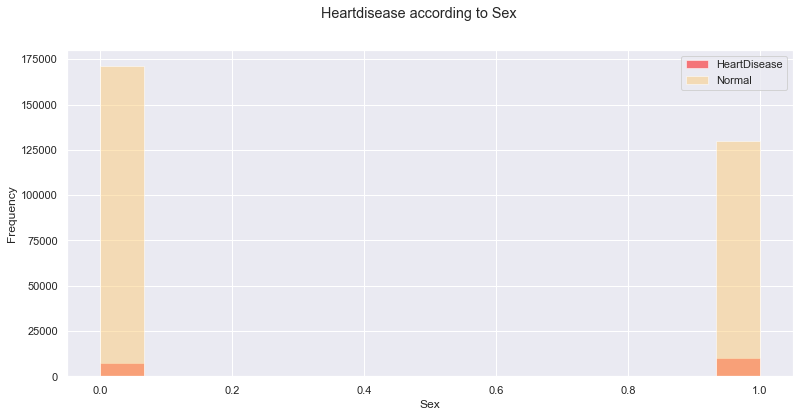

In [8]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["Sex"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["Sex"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("Sex")
ax.set_ylabel("Frequency")

fig.suptitle("Heartdisease according to Sex")

ax.legend();

Heartdisease is more prevalent in males.

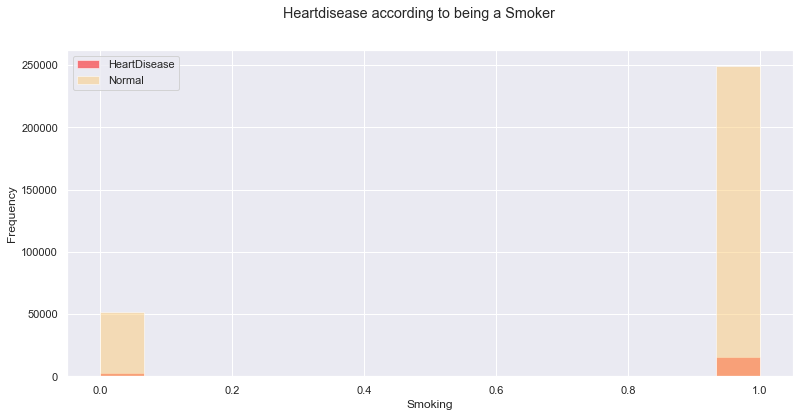

In [9]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["Smoking"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["Smoking"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("Smoking")
ax.set_ylabel("Frequency")

fig.suptitle("Heartdisease according to being a Smoker")

ax.legend();

Heartdisease is more prevalent in Smokers.

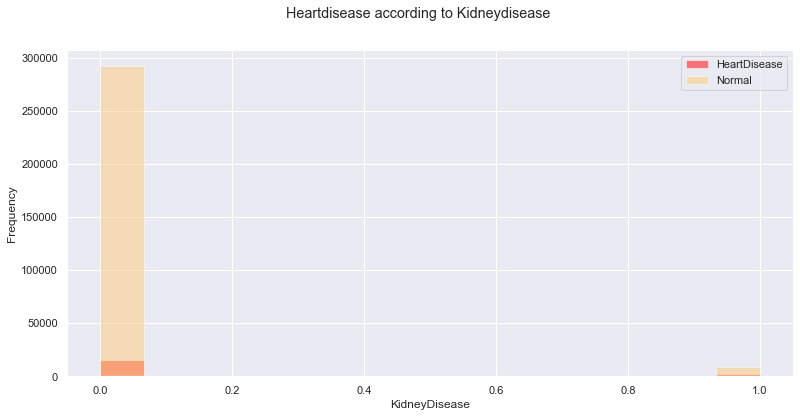

In [10]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["KidneyDisease"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["KidneyDisease"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("KidneyDisease")
ax.set_ylabel("Frequency")

fig.suptitle("Heartdisease according to Kidneydisease")

ax.legend();

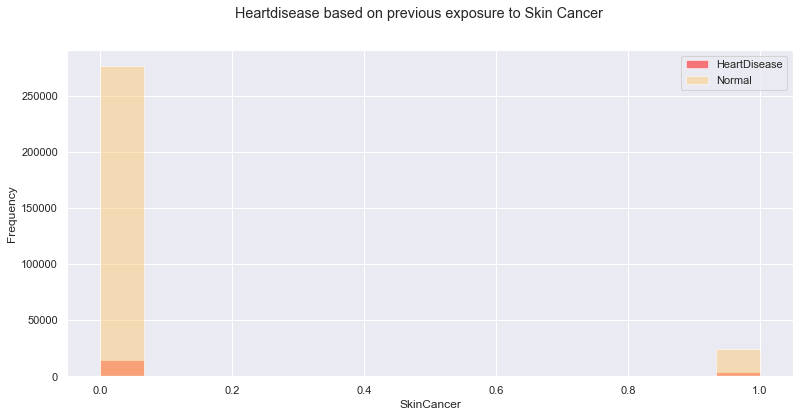

In [11]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["SkinCancer"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["SkinCancer"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("SkinCancer")
ax.set_ylabel("Frequency")

fig.suptitle("Heartdisease based on previous exposure to Skin Cancer")

ax.legend();

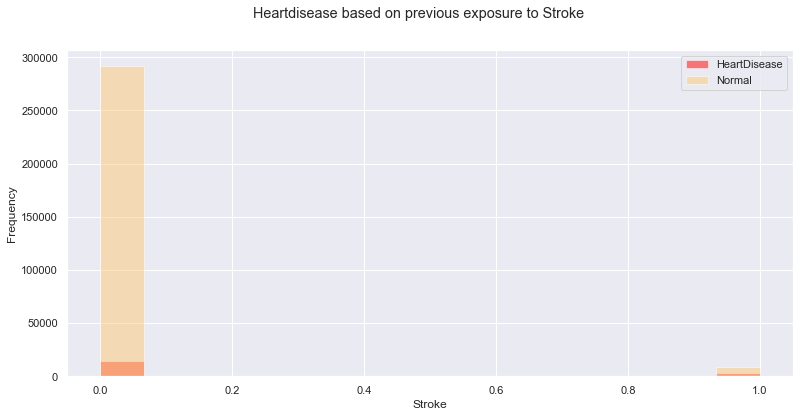

In [12]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["Stroke"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["Stroke"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("Stroke")
ax.set_ylabel("Frequency")

fig.suptitle("Heartdisease based on previous exposure to Stroke")

ax.legend();

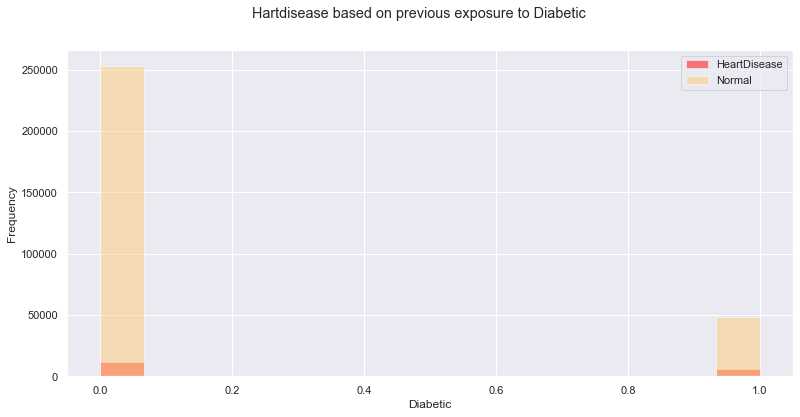

In [13]:
fig, ax = plt.subplots(figsize = (13,6))

ax.hist(df[df["HeartDisease"]==1]["Diabetic"], bins=15, alpha=0.5, color="red", label="HeartDisease")
ax.hist(df[df["HeartDisease"]==0]["Diabetic"], bins=15, alpha=0.5, color="#fccc79", label="Normal")

ax.set_xlabel("Diabetic")
ax.set_ylabel("Frequency")

fig.suptitle("Hartdisease based on previous exposure to Diabetic")

ax.legend();

<AxesSubplot:>

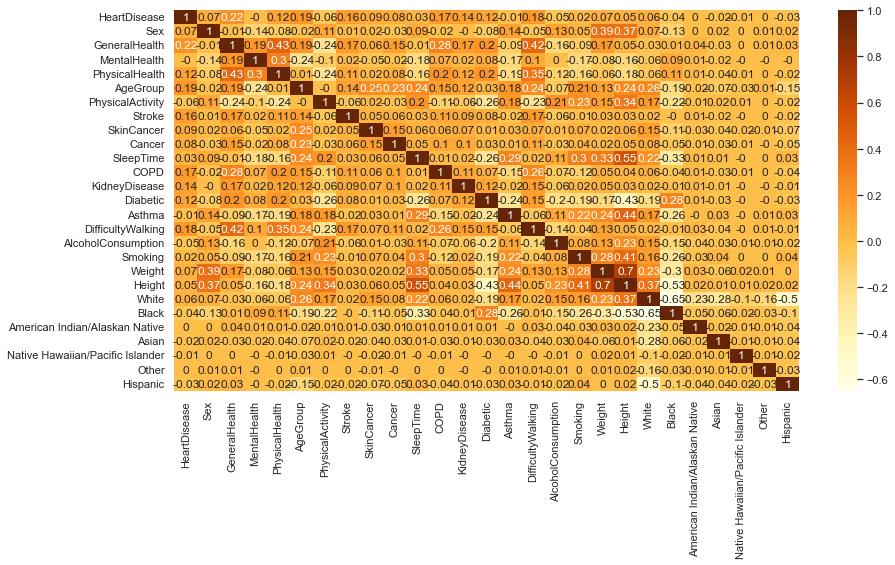

In [14]:
correlation = df.corr().round(2)
plt.figure(figsize = (14,7))
sns.heatmap(correlation, annot = True, cmap = 'YlOrBr')

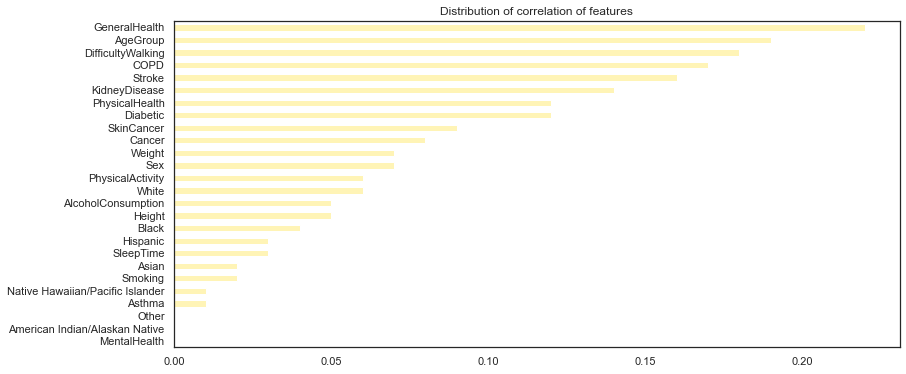

In [15]:
sns.set_style('white')
sns.set_palette('YlOrBr')
plt.figure(figsize = (13,6))
plt.title('Distribution of correlation of features')
abs(correlation['HeartDisease']).sort_values()[:-1].plot.barh()
plt.show()

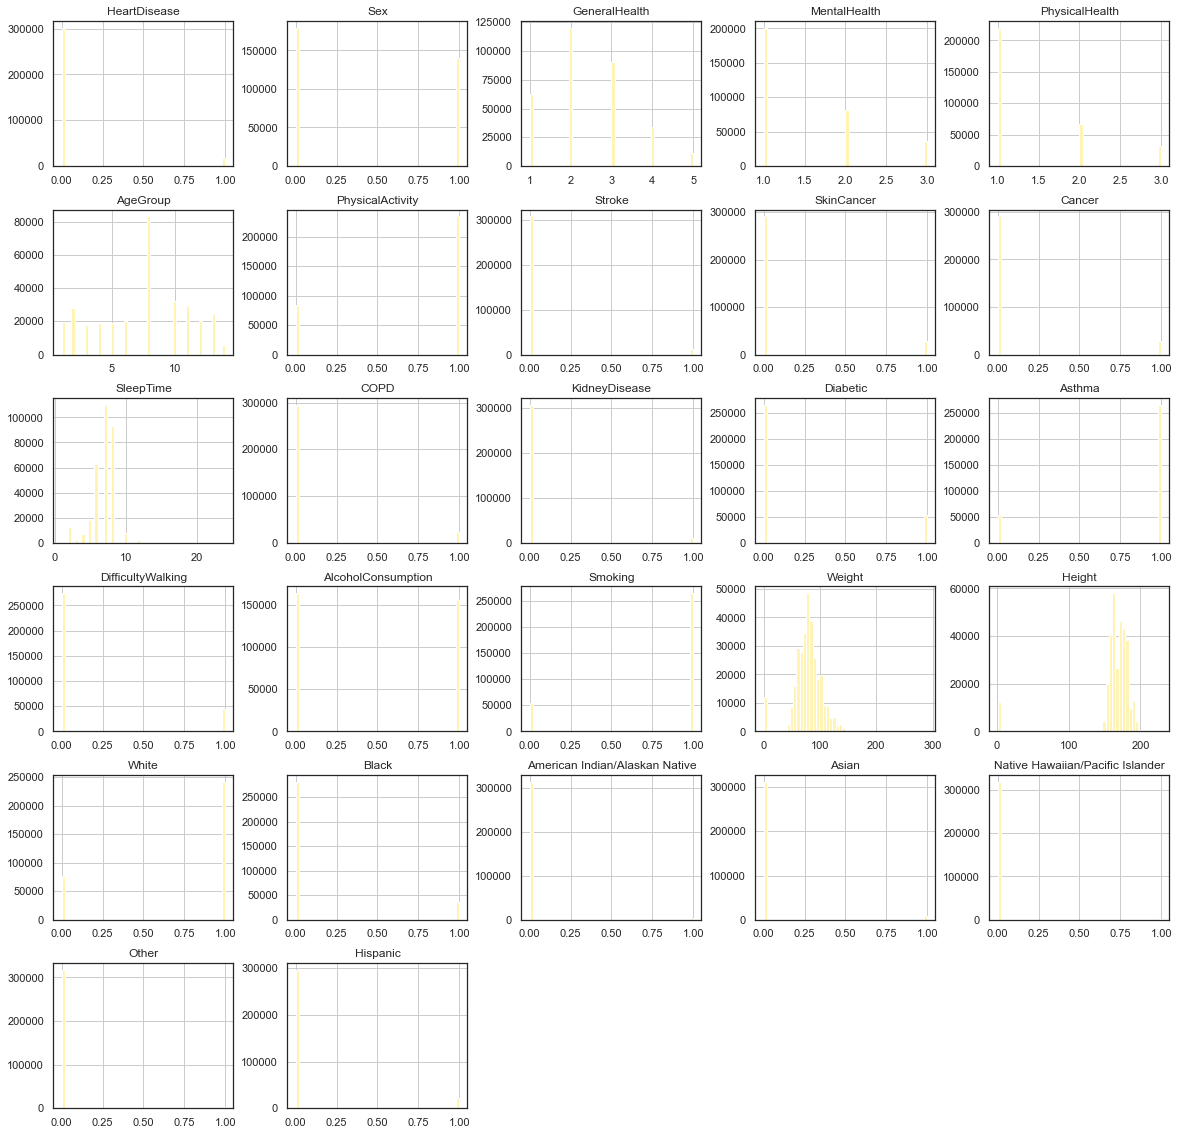

In [16]:
df.hist(bins=50, figsize=(20,20))
plt.show()

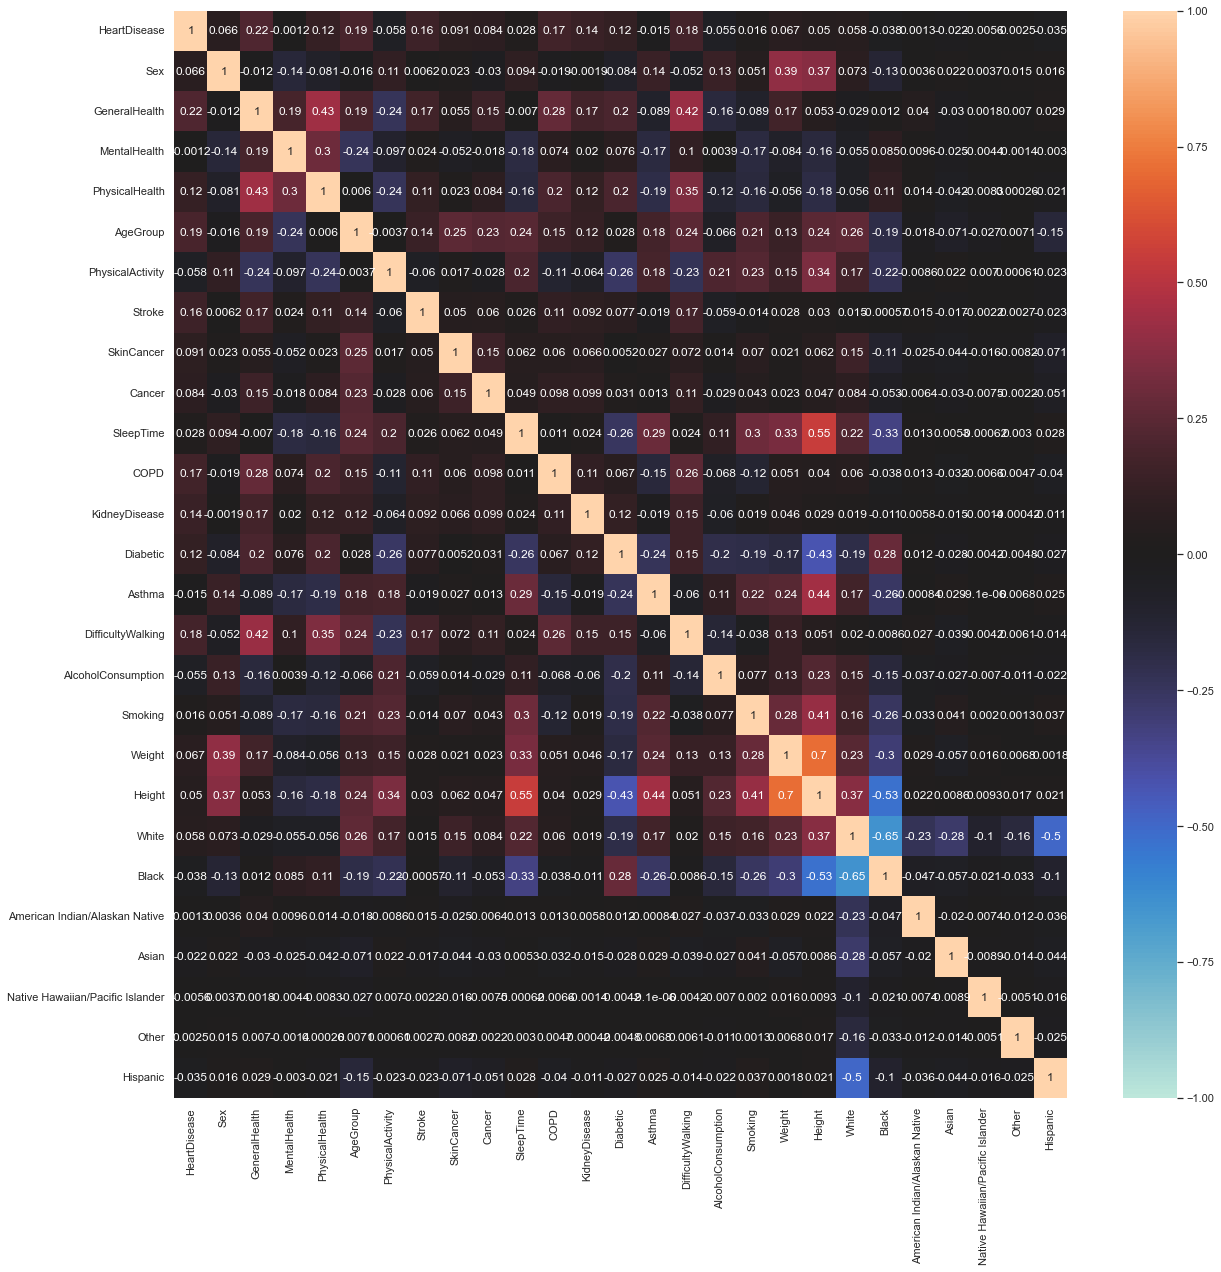

In [17]:
corr_plot = df.corr()
plt.figure(figsize = (20,20))
sns_plot=sns.heatmap(corr_plot, annot=True, vmin=-1, vmax=1, center=0)
plt.show()

Heart disease seems to be correlated with age, stroke, walking, physical health, diabetic, kidney disease, skin cancer, and sex.

Walking is correlated with physical health.

Physical health is correlated with mental health.

In [18]:
df.corr()

,HeartDisease,Sex,GeneralHealth,MentalHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,...,Smoking,Weight,Height,White,Black,American Indian/Alaskan Native,Asian,Native Hawaiian/Pacific Islander,Other,Hispanic
HeartDisease,1.000000,0.065576,0.215875,-0.001173,0.123069,0.191569,-0.057807,0.155673,0.091282,0.084318,...,0.016070,0.066531,0.049720,0.057644,-0.038164,0.001349,-0.022394,-0.005595,0.002489,-0.034946
Sex,0.065576,1.000000,-0.011872,-0.142239,-0.081191,-0.015945,0.105445,0.006246,0.023125,-0.029564,...,0.050623,0.391001,0.374916,0.072947,-0.126612,0.003584,0.021547,0.003688,0.014525,0.016221
GeneralHealth,0.215875,-0.011872,1.000000,0.187037,0.430727,0.191343,-0.236441,0.169123,0.055481,0.149975,...,-0.089109,0.167578,0.053316,-0.029439,0.012052,0.040160,-0.030352,0.001788,0.006974,0.028879
MentalHealth,-0.001173,-0.142239,0.187037,1.000000,0.298034,-0.238623,-0.096889,0.024307,-0.051559,-0.017776,...,-0.168457,-0.084331,-0.160320,-0.055498,0.085385,0.009610,-0.024661,-0.004377,-0.001351,-0.003009
PhysicalHealth,0.123069,-0.081191,0.430727,0.298034,1.000000,0.005985,-0.238730,0.110311,0.023272,0.083665,...,-0.157694,-0.055546,-0.182371,-0.056166,0.107451,0.014184,-0.042303,-0.008315,0.000257,-0.020804
AgeGroup,0.191569,-0.015945,0.191343,-0.238623,0.005985,1.000000,-0.003688,0.135347,0.252402,0.226912,...,0.205491,0.133064,0.242427,0.263750,-0.188075,-0.018412,-0.070811,-0.026847,0.007054,-0.147955
PhysicalActivity,-0.057807,0.105445,-0.236441,-0.096889,-0.238730,-0.003688,1.000000,-0.060137,0.016944,-0.028397,...,0.232806,0.149636,0.342278,0.173206,-0.220892,-0.008562,0.021912,0.006996,0.000610,-0.022559
Stroke,0.155673,0.006246,0.169123,0.024307,0.110311,0.135347,-0.060137,1.000000,0.050035,0.060480,...,-0.013520,0.027683,0.030323,0.015443,-0.000567,0.014798,-0.016581,-0.002198,0.002671,-0.022762
SkinCancer,0.091282,0.023125,0.055481,-0.051559,0.023272,0.252402,0.016944,0.050035,1.000000,0.150164,...,0.069938,0.021246,0.061717,0.151218,-0.107734,-0.025459,-0.044030,-0.015551,-0.008202,-0.071318
Cancer,0.084318,-0.029564,0.149975,-0.017776,0.083665,0.226912,-0.028397,0.060480,0.150164,1.000000,...,0.042926,0.022622,0.047273,0.084146,-0.052593,-0.006361,-0.029934,-0.007535,-0.002196,-0.050514


In [19]:
# Drop unrelated variables (less than 0.05 correlation with heart disease)
df.drop(['SleepTime', 'Asthma', 'MentalHealth', 'American Indian/Alaskan Native', 'Asian', 'Black', 'Hispanic', 'Native Hawaiian/Pacific Islander', 'Other', 'Height', 'Weight', 'Smoking'],axis=1,inplace=True)

In [20]:
df.corr()

,HeartDisease,Sex,GeneralHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,COPD,KidneyDisease,Diabetic,DifficultyWalking,AlcoholConsumption,White
HeartDisease,1.000000,0.065576,0.215875,0.123069,0.191569,-0.057807,0.155673,0.091282,0.084318,0.170049,0.140542,0.115289,0.178568,-0.054740,0.057644
Sex,0.065576,1.000000,-0.011872,-0.081191,-0.015945,0.105445,0.006246,0.023125,-0.029564,-0.018516,-0.001941,-0.083672,-0.052468,0.134937,0.072947
GeneralHealth,0.215875,-0.011872,1.000000,0.430727,0.191343,-0.236441,0.169123,0.055481,0.149975,0.278879,0.174446,0.202816,0.416885,-0.156494,-0.029439
PhysicalHealth,0.123069,-0.081191,0.430727,1.000000,0.005985,-0.238730,0.110311,0.023272,0.083665,0.196763,0.116000,0.201938,0.349568,-0.120661,-0.056166
AgeGroup,0.191569,-0.015945,0.191343,0.005985,1.000000,-0.003688,0.135347,0.252402,0.226912,0.153926,0.122161,0.027907,0.244795,-0.066069,0.263750
PhysicalActivity,-0.057807,0.105445,-0.236441,-0.238730,-0.003688,1.000000,-0.060137,0.016944,-0.028397,-0.114992,-0.063940,-0.260615,-0.231782,0.209333,0.173206
Stroke,0.155673,0.006246,0.169123,0.110311,0.135347,-0.060137,1.000000,0.050035,0.060480,0.108506,0.091901,0.076551,0.174106,-0.059362,0.015443
SkinCancer,0.091282,0.023125,0.055481,0.023272,0.252402,0.016944,0.050035,1.000000,0.150164,0.059706,0.066226,0.005173,0.071635,0.013877,0.151218
Cancer,0.084318,-0.029564,0.149975,0.083665,0.226912,-0.028397,0.060480,0.150164,1.000000,0.097827,0.099491,0.030693,0.114193,-0.029204,0.084146
COPD,0.170049,-0.018516,0.278879,0.196763,0.153926,-0.114992,0.108506,0.059706,0.097827,1.000000,0.106307,0.067352,0.255143,-0.068088,0.059959


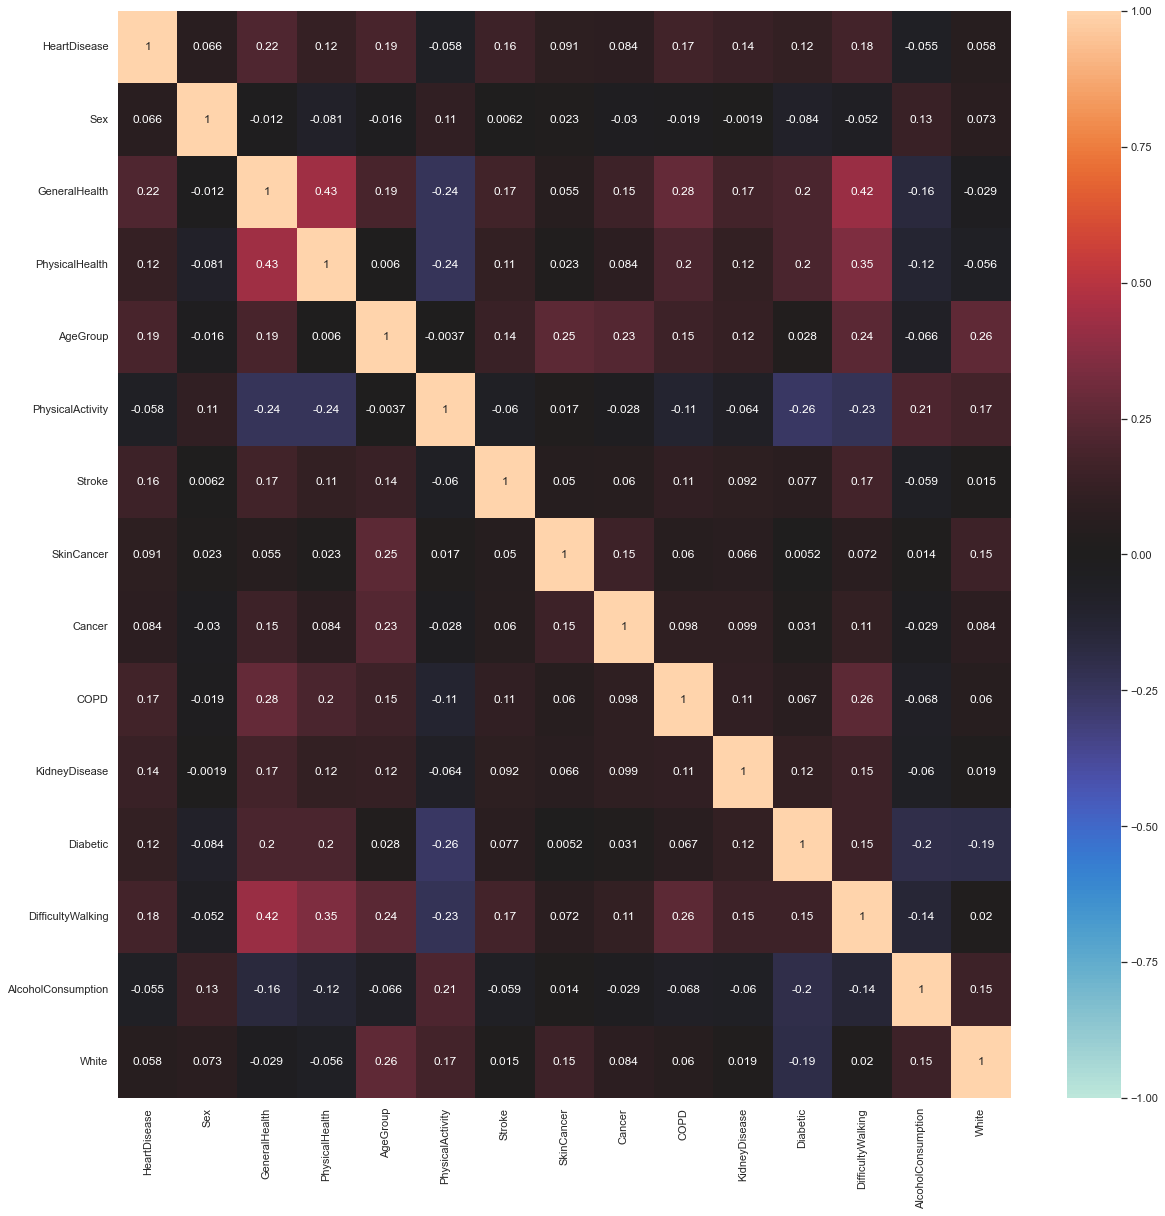

In [21]:
corr_plot = df.corr()
plt.figure(figsize = (20,20))
sns_plot=sns.heatmap(corr_plot, annot=True, vmin=-1, vmax=1, center=0)
plt.show()

## Variable Test Accuracy Analysis (Random Forest)

In [22]:
df.shape

(318924, 15)

In [23]:
x = df.drop('HeartDisease',axis=1)
y = df['HeartDisease']
print(f' x_shape: {x.shape} \n y_shape: {y.shape}')

 x_shape: (318924, 14) 
 y_shape: (318924,)


In [24]:
y.value_counts() 

0.0    301252
1.0     17672
Name: HeartDisease, dtype: int64

In [25]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=1)
x_res, y_res = rus.fit_resample(x,y)

In [26]:
print(f' x_shape: {x_res.shape} \n y_shape: {y_res.shape}')

 x_shape: (35344, 14) 
 y_shape: (35344,)


In [27]:
y_res.value_counts() 

0.0    17672
1.0    17672
Name: HeartDisease, dtype: int64

In [28]:
# No Undersampling
scl = StandardScaler()
x = scl.fit_transform(x)

In [29]:
# Undersampling
scl = StandardScaler()
x_res = scl.fit_transform(x_res)

In [30]:
# No Undersampling
x_train, x_valid, y_train, y_test = train_test_split(x,y,test_size=0.20,shuffle=True,random_state=0)
print(f' x_train: {x_train.shape} & x_valid: {x_valid.shape}')
print(f' y_train: {y_train.shape} & y_test: {y_test.shape}')

 x_train: (255139, 14) & x_valid: (63785, 14)
 y_train: (255139,) & y_test: (63785,)


In [31]:
# Undersampling
x_train_res, x_valid_res, y_train_res, y_test_res = train_test_split(x_res,y_res,test_size=0.20,shuffle=True,random_state=0)
print(f' x_train: {x_train_res.shape} & x_valid: {x_valid_res.shape}')
print(f' y_train: {y_train_res.shape} & y_test: {y_test_res.shape}')

 x_train: (28275, 14) & x_valid: (7069, 14)
 y_train: (28275,) & y_test: (7069,)


In [32]:
rf_clf = RandomForestClassifier(criterion='entropy',n_estimators=20)

rf_clf.fit(x_train, y_train)
y_pred_test = rf_clf.predict(x_valid)
y_pred_train = rf_clf.predict(x_train)

In [33]:
rf_clf_res = RandomForestClassifier(criterion='entropy',n_estimators=20)

rf_clf_res.fit(x_train_res, y_train_res)
y_pred_test_res = rf_clf_res.predict(x_valid_res)
y_pred_train_res = rf_clf_res.predict(x_train_res)

In [34]:
print('Accuracy of Train befor Undersampling: {}'.format(accuracy_score(y_train, y_pred_train)*100))
print('Accuracy of Test befor Undersampling: {}'.format(accuracy_score(y_test,y_pred_test)*100))
print('********************************************************')
print('Accuracy of Train after Undersampling: {}'.format(accuracy_score(y_train_res,y_pred_train_res)*100))
print('Accuracy of Test after Undersampling: {}'.format(accuracy_score(y_test_res,y_pred_test_res)*100))

Accuracy of Train befor Undersampling: 95.81443840416401
Accuracy of Test befor Undersampling: 93.75244963549424
********************************************************
Accuracy of Train after Undersampling: 85.62334217506631
Accuracy of Test after Undersampling: 75.11670674777197


In [35]:
print(confusion_matrix(y_test_res, y_pred_test_res))

[[2586  949]
 [ 810 2724]]


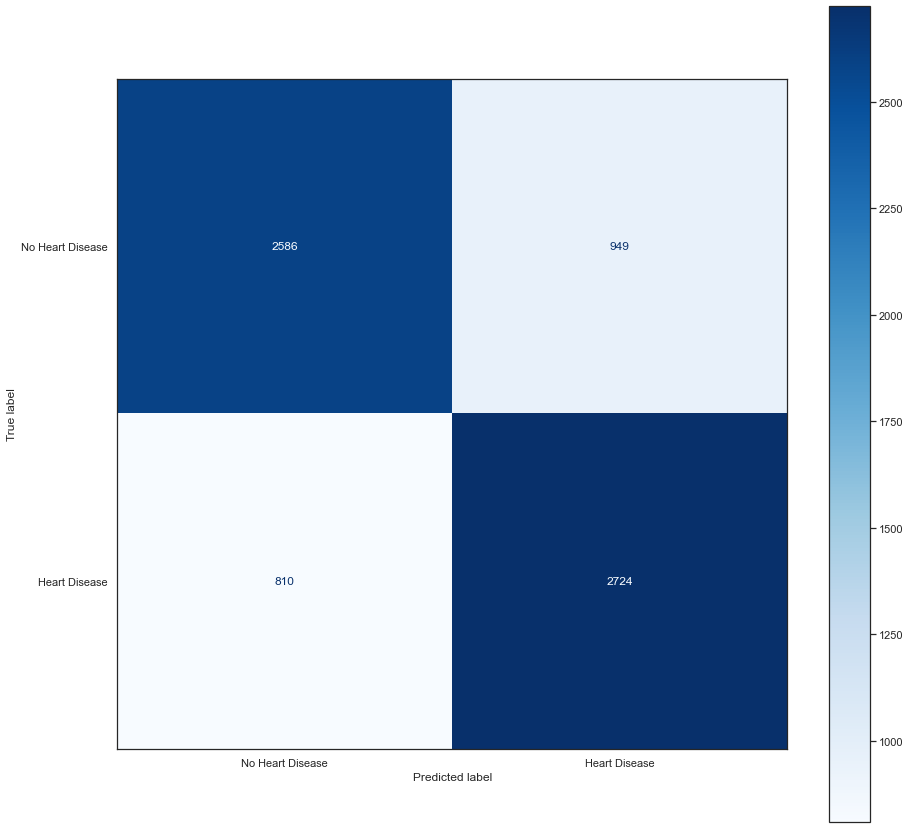

In [36]:
disp = plot_confusion_matrix(rf_clf_res, x_valid_res, y_test_res, display_labels=['No Heart Disease','Heart Disease'], cmap=plt.cm.Blues)

In [37]:
precision_score(y_test, y_pred_test)

0.28116213683223995

In [38]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     60267
         1.0       0.28      0.09      0.13      3518

    accuracy                           0.94     63785
   macro avg       0.61      0.54      0.55     63785
weighted avg       0.91      0.94      0.92     63785



In [39]:
rforest_perform_train = []
rforest_perform_valid = []
r_undersample = np.linspace(0.1,1,9)
rforest = rf_clf

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i)
    x_res, y_res = rus.fit_resample(x_train,y_train)                   
    rforest.fit(x_valid_res, y_test_res)   
    rforest_perform_train.append((recall_score(y_res,rforest.predict(x_res)),precision_score(y_res,rforest.predict(x_res))))
    rforest_perform_valid.append((recall_score(y_test,rforest.predict(x_valid)),precision_score(y_test,rforest.predict(x_valid))))

In [40]:
def undersample_plot(r_undersample,perform_train,perform_valid,title):
    plt.figure()
    plt.plot(r_undersample,[x[0] for x in perform_train],color='k',linewidth=3)
    plt.plot(r_undersample,[x[1] for x in perform_train],color='k')
    plt.plot(r_undersample,[x[0] for x in perform_valid],color='k',linestyle='--',linewidth=3)
    plt.plot(r_undersample,[x[1] for x in perform_valid],color='k',linestyle='--')
    legend = ['Recall (Training)','Precision (Training)','Recall (Validation)','Precision (Validation)']
    plt.legend(legend)
    plt.xlabel('Undersampling ratio')
    plt.title(title)
    plt.ylim(0,1)
    plt.show()

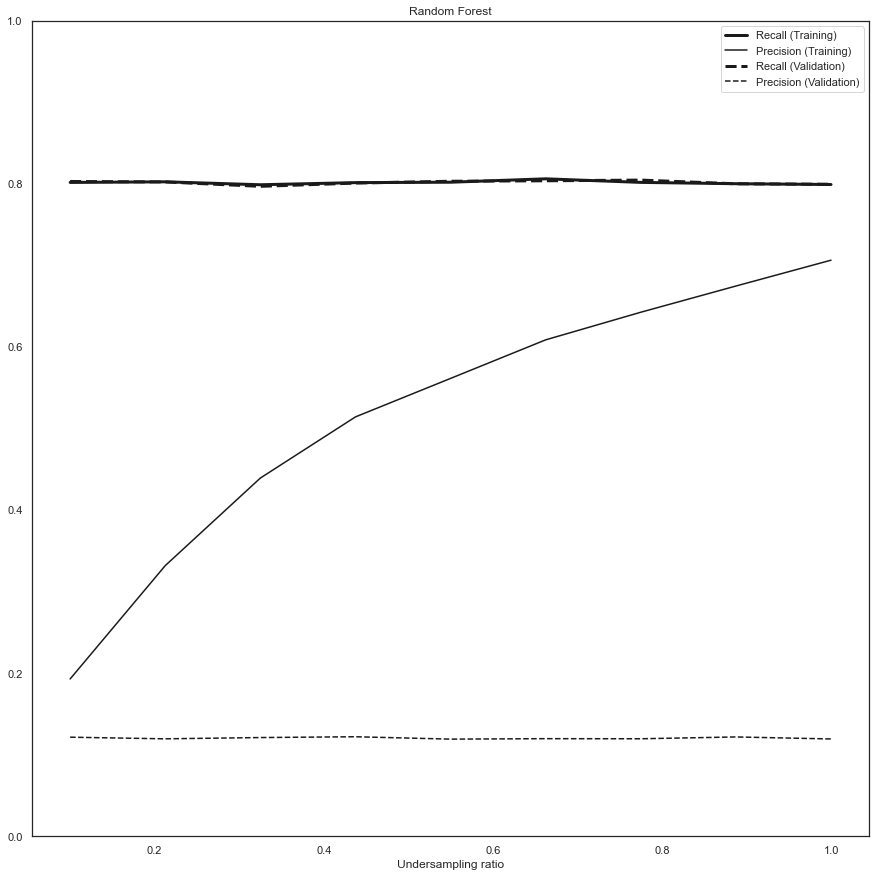

In [41]:
undersample_plot(r_undersample,rforest_perform_train,rforest_perform_valid,'Random Forest')

In [42]:
print(classification_report(y_test, rforest.predict(x_valid)))

              precision    recall  f1-score   support

         0.0       0.98      0.66      0.79     60267
         1.0       0.12      0.80      0.21      3518

    accuracy                           0.66     63785
   macro avg       0.55      0.73      0.50     63785
weighted avg       0.93      0.66      0.75     63785

